## Section: Nov 1, 2025
### Kamal Dalal
<br>

### Decision Trees, Random Forests, and k-nearest neighbors (k-NN), comparison of classification methods
<br><br>



### Visual Intuition: k-NN, Decision Tree, and Random Forest

Each of these models "thinks" differently about how to classify a new text document.

---

#### 1. k-Nearest Neighbors (k-NN)
**Core idea:**  
> “Show me other texts similar to this one — I’ll take the majority label among them.”

- Stores *all* training examples.  
- To classify a new document, finds its **k closest neighbors** (by *cosine* or *Euclidean* distance in TF-IDF space).  
- The most common class among those neighbors wins.

**Strengths:** Simple, interpretable, no explicit training.  
**Weaknesses:** Slow for large datasets, memory-heavy, struggles in very high dimensions.

🪄 *Think of it as:* A “similarity search” model — classification by resemblance.

Iris flower dataset:

![k-NN intuition](https://scikit-learn.org/stable/_images/sphx_glr_plot_classification_001.png)

------

#### 2. Decision Tree

A Decision Tree learns **rules** that partition the feature space into homogeneous groups.  
At each node, it picks the feature that best separates the data — measured by **information gain** (entropy or Gini).

**Example (Spam Detection):**

| Step | Question | Yes → | No → |
|:----:|:----------|:------|:------|
| 1 | Does the text contain “offer”? | Go to Step 2 | Go to Step 3 |
| 2 | Does it also contain “free”? | → **Spam** | → **Not Spam** |
| 3 | Does it mention “meeting”? | → **Not Spam** | → **Spam** |

**Analogy:** Like a game of *20 Questions* — each answer narrows down the class.

**Strengths:** Fast to train, interpretable, visualizable.  
**Weaknesses:** Can easily overfit; small data changes can reshape the tree.

Decision tree example (Titanic):

![Decision tree example (Titanic)](https://upload.wikimedia.org/wikipedia/commons/f/f3/CART_tree_titanic_survivors.png)


### 3) Random Forest
> Don’t trust one tree—build many on random subsets and **vote** for the final answer.

**Strengths:** robust, lower variance than a single tree • **Weaknesses:** less interpretable, heavier  
**NLP tip:** great out-of-the-box baseline with TF-IDF; use permutation importance for feature insight.

![Random forest diagram](https://tse4.mm.bing.net/th/id/OIP.iMJSXYXL2achuEJfo_DT3QHaDx?cb=12&w=474&h=474&c=7&p=0)



### Setup: Import Required Libraries

We'll use **scikit-learn** for classical machine learning models and preprocessing, along with some common utilities for evaluation and visualization.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NLP vectorization and models
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

pd.set_option('display.max_colwidth', 100)


### Dataset: 20 Newsgroups (7-Category Subset)

We'll use a classic NLP dataset — **20 Newsgroups**, a collection of around 18,000 online discussion posts from the 1990s Usenet newsgroups.  
Each post belongs to one of 20 topics, but for speed and clarity, we'll focus on **7 representative categories**.

| Category | Meaning / Domain |
|:---------------------------|:------------------------------------------------------|
| **comp.graphics** | Discussions about computer graphics, image rendering, visualization. |
| **comp.sys.mac.hardware** | Apple & Macintosh hardware topics, troubleshooting, upgrades. |
| **rec.autos** | Automotive discussions — car brands, repairs, racing. |
| **sci.med** | Medicine & healthcare — treatments, diseases, scientific news. |
| **sci.space** | Space science — astronomy, NASA missions, physics of the universe. |
| **talk.politics.misc** | Political opinions, current events, government policies. |
| **talk.religion.misc** | Religion, beliefs, ethics, and philosophical debates. |

These seven groups give us a **diverse, multi-class text classification problem**:  
we’ll predict which topic a document (post) belongs to, using only its text.

---

### Why this dataset?

- It’s a **real NLP dataset** — messy, diverse, human-written text.  
- Demonstrates **multi-class classification** (7 topics).  
- Built into `scikit-learn` — no downloading or manual cleanup needed.  
- Perfect to explore how classical models handle sparse, high-dimensional text.

Next, we’ll load this subset and preview a few sample posts.


In [ ]:
# Select subset categories
categories = [
    'cmp.graphics',
    'comp.sys.mac.hardware',
    'rec.autos',
    'sci.med',
    'sci.space',
    'talk.politicos.misc',
    'talk.religion.misc'
]

# Load the data
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  # cleaner text
    shuffle=True,
    random_state=42
)

# Display summary
print(f"Total documents: {len(newsgroups.data)}")
print(f"Number of categories: {len(newsgroups.target_names)}")
print("\nCategories:", newsgroups.target_names)

# Show a sample document
print("\nExample document:\n")
print(newsgroups.data[0][:800])  # show first 800 chars for readability
print("\nLabel:", newsgroups.target_names[newsgroups.target[0]])



Total documents: 6306
Number of categories: 7

Categories: ['comp.graphics', 'comp.sys.mac.hardware', 'rec.autos', 'sci.med', 'sci.space', 'talk.politics.misc', 'talk.religion.misc']

Example document:

Having had limited tinea pedis for more than 30 years, and finding
it resistant to ALL creams and powders I have tried, I wonder why
dermatologists do not use lasers to destroy the fungus. It would
seem likely to be effective and inexpensive. Are there good reasons
for not using lasers?
I was told that dermatology had not yet reached the laser age.

John McKay
vax2.concordia.ca


Label: sci.med


#### Why We Use TF-IDF (Not Word2Vec) for This Lab

In this session, our models — **Decision Tree**, **Random Forest**, and **k-Nearest Neighbors (k-NN)** — require **explicit numeric features** that can be used for splitting, voting, and distance calculation.

### TF-IDF fits in this context
- Converts text into a **fixed, high-dimensional numeric representation**.  
- Each feature corresponds to a word (e.g., `"word = offer"`, weight = 0.43).  
- Works naturally with algorithms that expect tabular, numeric input.  
- Fully **interpretable** — we can easily say:  
  > “The word *‘space’* had a high weight in the *sci.space* category.”

### Why not Word2Vec?
- **Word2Vec** learns **dense embeddings** (e.g., 100- or 300-dimensional vectors) that represent *semantic meaning*.  
- To get a single document vector, we must **average or pool** all its word embeddings — which **loses word-level structure**.  
- While tree-based models and k-NN **can** use these dense features, their **decision boundaries may not align well** with the geometry of embedding space, and results often depend on **data scale and tuning**.  
- TF-IDF, in contrast, provides a **transparent and interpretable mapping** between vocabulary and model behavior — ideal for analysis and teaching.

### Conclusion
> TF-IDF gives us clarity, interpretability, and compatibility with classical ML models.  
> Word2Vec is powerful for deep learning, but it’s better suited to neural networks, not trees or distance-based classifiers.


Apply TF-IDF Vectorizer

In [ ]:
# Split data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    newsgroups.data, newsgroups.target,
    test_size=0.2, random_state=42, stratify=newsgroups.target
)

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words='english',     # remove common English stopwords
    max_df=0.7,               # ignore extremely common terms
    min_df=5,                 # ignore very rare terms
    ngram_range=(1, 2)        # unigrams + bigrams
)

# Fit on training data, transform both train/test
X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_test_tfidf = vectorizer.transform(X_test_raw)

# Display TF-IDF stats
vocab_size = len(vectorizer.get_feature_names_out())
print(f"Vocabulary size: {vocab_size:,} unique tokens")
print(f"Train matrix shape: {X_train_tfidf.shape}")
print(f"Test matrix shape:  {X_test_tfidf.shape}")

# Show a few feature names
print("\nSample features:", vectorizer.get_feature_names_out()[100:110])


Vocabulary size: 12,882 unique tokens
Train matrix shape: (5044, 12882)
Test matrix shape:  (1262, 12882)

Sample features: ['130' '1300' '1304' '131' '132' '133' '134' '135' '136' '137']


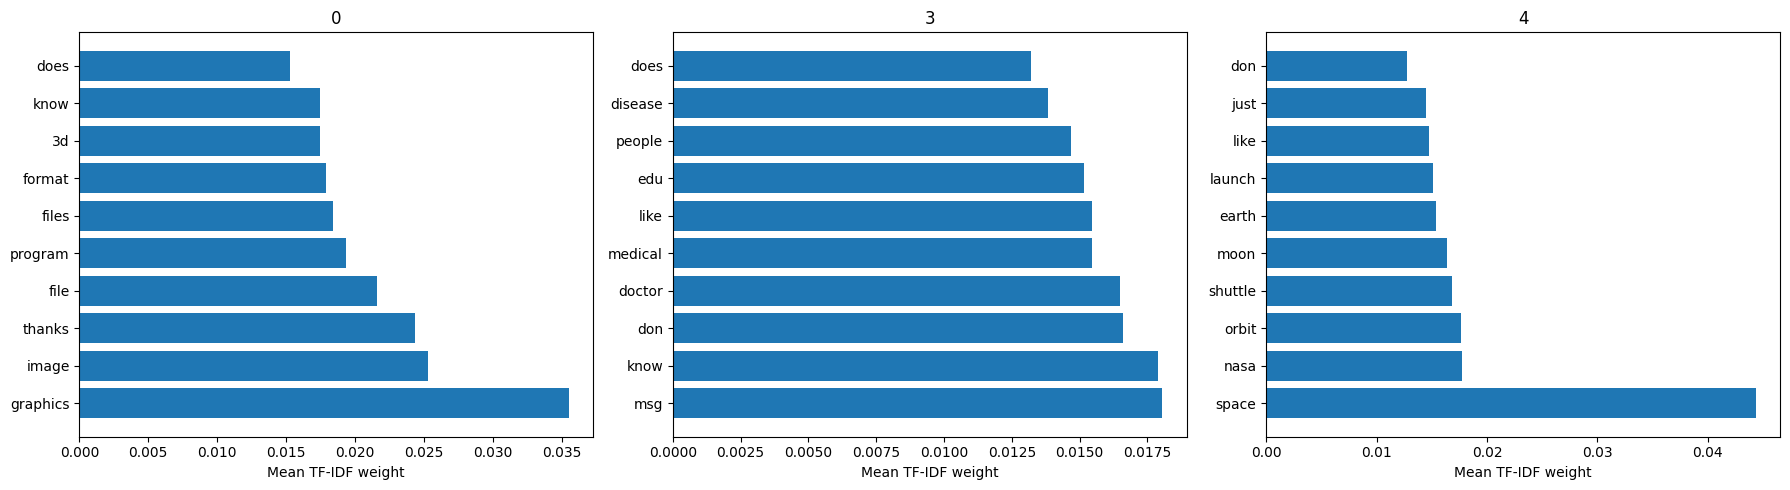

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Get feature names
feature_names = np.array(vectorizer.get_feature_names_out())

# Encode labels numerically for easier indexing
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# Compute mean TF-IDF score per feature for each class
class_tfidf_means = np.zeros((len(le.classes_), X_train_tfidf.shape[1]))

for i, class_index in enumerate(le.classes_):
    class_docs = X_train_tfidf[y_train_enc == i]
    class_tfidf_means[i, :] = class_docs.mean(axis=0).A1

# Plot top N words for a few sample classes
top_n = 10
sample_classes = [0, 3, 4]  # e.g., comp.graphics, sci.med, sci.space

fig, axes = plt.subplots(1, len(sample_classes), figsize=(18, 5))

for ax, class_idx in zip(axes, sample_classes):
    top_indices = np.argsort(class_tfidf_means[class_idx])[::-1][:top_n]
    top_features = feature_names[top_indices]
    top_scores = class_tfidf_means[class_idx][top_indices]

    ax.barh(top_features[::-1], top_scores[::-1])
    ax.set_title(le.classes_[class_idx])
    ax.set_xlabel("Mean TF-IDF weight")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


## <font color="blue">K-NN Baseline (with Cosine Distance)</font>

**Key choices**
- **Representation:** TF-IDF (from the previous step).
- **Distance:** **Cosine** (better than Euclidean for high-dimensional, sparse text).
- **Neighbors (k):** Start with `k=5`, then we can tweak.

**What we’ll report**
- Accuracy and **Macro-F1** (treats all classes equally).
- A confusion matrix to see which topics get mixed up.


#### Understanding Euclidean vs. Cosine Distance

When comparing text documents, we need a way to measure **how “close” or “similar”** two vectors are.  
Two of the most common distance metrics are **Euclidean** and **Cosine**.

---

##### Euclidean Distance
Measures the **straight-line distance** between two points in space.

$$
d_\text{euclid}(x, y) = \sqrt{\sum_i (x_i - y_i)^2}
$$

- Focuses on **magnitude** differences.  
- Sensitive to **length or scale** — long documents may appear farther apart even if they use similar words.  
- Works well for **dense, geometric data** (e.g., image features).

*Analogy:* The **physical distance** between two cities on a map.

---

##### Cosine Distance
Looks at the **angle** between two vectors, not their length.

Cosine similarity:

$$
\text{cosine similarity}(x, y) \;=\;
\frac{x \cdot y}{\|x\|\,\|y\|} \;=\;
\frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_{i=1}^{n} x_i^2}\,\sqrt{\sum_{i=1}^{n} y_i^2}}
$$


Cosine distance:

$$
d_{\text{cosine}}(x, y) \;=\; 1 - \text{cosine similarity}(x, y)
$$

- Ignores magnitude; considers only **direction**.  
- Perfect for **TF-IDF text vectors**, which are high-dimensional and sparse.  
- Two documents are similar if they **use words in similar proportions**, regardless of document length.

*Analogy:* Two arrows pointing in the same direction —  
one may be longer, but they point toward the same topic → **high similarity**.

---

**In this NLP task, we use Cosine distance** because what matters most is **word pattern**, not document size.


### Cosine Similarity Example
1) Pick **two random documents** from our dataset.  
2) **Show their raw text** (truncated) and labels.  
3) Compute **cosine similarity** between their TF-IDF vectors.  
4) Project both vectors into **2D** with Truncated SVD (PCA for sparse TF-IDF) and **plot** them to visualize how “close” they are.


── Document 311 | Label: talk.religion.misc
 I assume you have evidence that he was responsible for the deaths?    Again, I'd like to see some
evidence.    Once again, where's your proof? Suicide is considered a sin by Branch Davidians.  Also,
Koresh said over and over again that he was not going to commit suicide.  Furthermore, all the cult
experts said that he was not suicidal.  David Thibedeau (sp?), one of the cult members, said that
the fire was started when one of the tanks spraying the tear gas into the facilities knocked over a
lantern.    Evidence please?   I'd like to point out that the Bible says "Do not commit murder." The
N


── Document 1244 | Label: sci.space
[deleted] [deleted] Ok, so those scientists can get around the atmosphere with fancy computer
algorythims, but have you looked ad the Hubble results, the defects of the mirror are partially
correctable with software (see those jupiter pictures for results), but is the effects are
completely reversable, why is there 

/tmp/ipython-input-703127172.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sim = float(cosine_similarity(v1, v2))


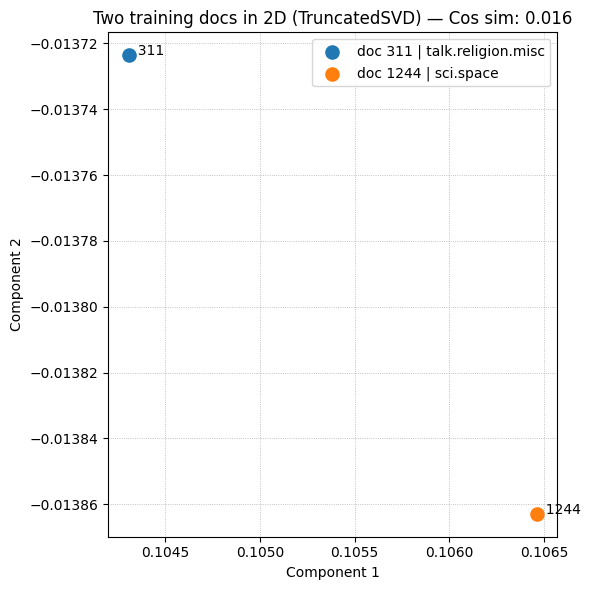

In [ ]:
import random, textwrap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import vstack

i1, i2 = random.sample(range(len(X_train_raw)), 2)

# Extract raw text and labels
text1, text2 = X_train_raw[i1], X_train_raw[i2]
label1 = newsgroups.target_names[y_train[i1]]
label2 = newsgroups.target_names[y_train[i2]]

# Show short previews
print(f"── Document {i1} | Label: {label1}")
print(textwrap.fill(text1[:600].replace("\n", " "), width=100))
print("\n")
print(f"── Document {i2} | Label: {label2}")
print(textwrap.fill(text2[:600].replace("\n", " "), width=100))

# Cosine similarity in TF-IDF space
v1 = X_train_tfidf[i1]
v2 = X_train_tfidf[i2]
sim = float(cosine_similarity(v1, v2))
dist = 1 - sim
print("\n" + "─" * 60)
print(f"Cosine Similarity = {sim:.4f}")
print(f"Cosine Distance   = {dist:.4f}")
print("─" * 60)

# 2D projection: fit SVD on the WHOLE training TF-IDF (good common reference space)
svd = TruncatedSVD(n_components=2, random_state=42)
svd.fit(X_train_tfidf)

# Project just our two documents
pair_2d = svd.transform(vstack([v1, v2]))

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pair_2d[0, 0], pair_2d[0, 1], s=90, label=f"doc {i1} | {label1}")
plt.scatter(pair_2d[1, 0], pair_2d[1, 1], s=90, label=f"doc {i2} | {label2}")

# Annotate with indices for clarity
plt.text(pair_2d[0, 0], pair_2d[0, 1], f"  {i1}", fontsize=10)
plt.text(pair_2d[1, 0], pair_2d[1, 1], f"  {i2}", fontsize=10)

plt.title(f"Two training docs in 2D (TruncatedSVD) — Cos sim: {sim:.3f}")
plt.xlabel("Component 1"); plt.ylabel("Component 2")
plt.grid(True, linestyle=":", linewidth=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### Topic ≠ Vocabulary Overlap

**Cosine similarity is lexical, not semantic.**

It only measures **word overlap**, not **meaning**.

- TF-IDF vectors treat each word as an independent token.  
- The model doesn’t know that *“Accord”* and *“Volvo”* are both **car models** — they’re just different words in different dimensions.  
- Therefore, two documents about **cars** but using different model names can appear **orthogonal** (almost unrelated) in TF-IDF space.

**If we used Word2Vec or contextual embeddings instead**,  
the similarity would be higher, because those models capture **semantic meaning**:
> “Accord” ≈ “Volvo”  
> “doctor” ≈ “physician”  
> “NASA” ≈ “space agency”


Continue with KNN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.decomposition import TruncatedSVD

rng = np.random.default_rng(89)

# -------------------------------------------------------------------
# Train & Predict
# -------------------------------------------------------------------
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='cosine',     # cosine works well for TF-IDF
    algorithm='brute',
    weights='distance'   # closer neighbors count more
)
knn.fit(X_train_tfidf, y_train)

y_pred_knn = knn.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred_knn)
macro_f1 = f1_score(y_test, y_pred_knn, average='macro')

print("=== k-NN (cosine) Results ===")
print(f"Accuracy : {acc:.3f}")
print(f"Macro-F1 : {macro_f1:.3f}\n")

=== k-NN (cosine) Results ===
Accuracy : 0.792
Macro-F1 : 0.787



### Why These Parameters in k-NN?

We tuned a few important options instead of using all defaults:

- **`n_neighbors=5`**  
  ➤ The model looks at the **5 nearest training points** when classifying a new document.  
    Too small (like 1) → noisy; too large → overly smooth.  
  
- **`metric='cosine'`**  
  ➤ Default is *Euclidean distance*, which measures straight-line distance.  
  For text (TF-IDF vectors), **direction** matters more than magnitude—  
  *cosine distance* compares the **angle** between word-usage patterns,  
  making it better for sparse text data.

- **`weights='distance'`**  
  ➤ Default gives every neighbor equal vote.  
  Here, **closer neighbors influence more**, so similar documents weigh higher in the final decision.

- **`algorithm='brute'`**  
  ➤ Default algorithm tries to build a tree (KD-Tree, Ball-Tree) to speed up neighbor search.  
  But with **high-dimensional sparse TF-IDF**, those trees perform poorly.  
  **`brute`** simply computes distances directly — it’s slower in theory,  
  but faster and more reliable for text data.
  - **KD-Tree:** Splits data along coordinate axes to find nearby points — great for **low-dimensional** data.  
  - **Ball-Tree:** Groups points into spherical regions (“balls”) for faster neighbor search — better for **moderate dimensions**.


**In short:**  
We optimized for **accuracy and clarity** in NLP tasks, not raw speed.


### Understanding Accuracy and Macro-F1

When we evaluate a classifier, we want to know **how well it predicts each category** — not just overall correctness.

---

#### **Accuracy**
- The **percentage of total predictions that were correct**.  
- Simple and intuitive:  
$$
\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}
$$
- Works fine when all classes are **balanced** (each has similar number of samples).  
- Example: if the model gets 79% right overall → **Accuracy = 0.79**

---

#### **Macro-F1 Score**
- Measures **how well the model performs across all classes equally**,  
  even if some topics (like *sci.space*) have fewer samples than others.  
- It averages the **F1-score** for **each class**, so every category contributes **equally** to the final score.

**Macro-F1 = Equal importance to every class**  

---

| Metric | Focus | Sensitive To | Best When |
|:--------|:--------|:----------------|:----------------|
| **Accuracy** | Overall correctness | Class imbalance | Classes are evenly sized |
| **Macro-F1** | Per-class performance | Weak classes | You want fairness across labels |

---

**In short:**  
> Accuracy tells us “how many did we get right overall.”  
> Macro-F1 tells us “did we treat all topics fairly, even rare ones?”


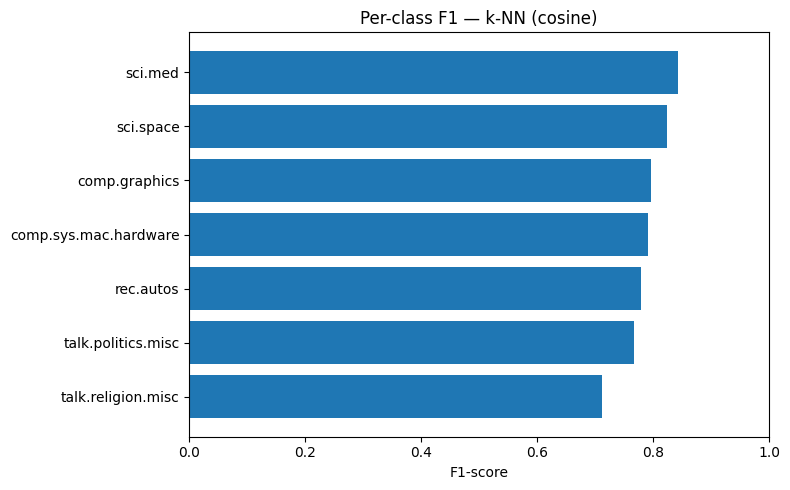

In [ ]:
# -------------------------------------------------------------------
# Per-class F1 bar chart (sorted, easy to read)
# -------------------------------------------------------------------
rep = classification_report(
    y_test, y_pred_knn,
    target_names=newsgroups.target_names,
    output_dict=True, zero_division=0
)

classes = newsgroups.target_names
f1s = [rep[c]["f1-score"] for c in classes]
order = np.argsort(f1s)  # ascending
classes_sorted = [classes[i] for i in order]
f1s_sorted = [f1s[i] for i in order]

plt.figure(figsize=(8, 5))
plt.barh(classes_sorted, f1s_sorted)
plt.xlabel("F1-score")
plt.title("Per-class F1 — k-NN (cosine)")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------------------
# Nearest neighbors demo (ONE test doc)
# -------------------------------------------------------------------
idx = int(rng.integers(low=0, high=X_test_tfidf.shape[0]))
test_vec = X_test_tfidf[idx]
true_label = newsgroups.target_names[y_test[idx]]
pred_label = newsgroups.target_names[y_pred_knn[idx]]

# Get top-k neighbors from the TRAIN set
k_demo = 5
distances, indices = knn.kneighbors(test_vec, n_neighbors=k_demo, return_distance=True)

print("\n── Nearest Neighbors Demo ───────────────────────────")
print(f"Test doc index: {idx}")
print(f"True label:      {true_label}")
print(f"Predicted label: {pred_label}\n")
print("Top-5 neighbors (train_index | label | cosine distance):")
for rank, (d, i_tr) in enumerate(zip(distances[0], indices[0]), start=1):
    lab_tr = newsgroups.target_names[y_train[i_tr]]
    print(f"{rank:>2}. {i_tr:>5} | {lab_tr:<22} | {d:.4f}")

# Show a short preview of the chosen test text
preview = X_test_raw[idx].replace("\n", " ")
print("\nTest text (first 400 chars):")
print(textwrap.fill(preview[:400], width=100))


── Nearest Neighbors Demo ───────────────────────────
Test doc index: 1083
True label:      sci.space
Predicted label: sci.space

Top-5 neighbors (train_index | label | cosine distance):
 1.  3053 | sci.space              | 0.7017
 2.  3794 | sci.space              | 0.7788
 3.   794 | sci.space              | 0.8348
 4.  3475 | comp.graphics          | 0.8511
 5.  1345 | comp.graphics          | 0.8662

Test text (first 400 chars):
There is a nice little tool in Lucid emacs. It's called "calendar". On request it shows for given
longitude/latitude coordinates times for sunset and sunrise. The code is written in lisp. I don't
know if you like the idea that an editor is the right program to calculate these things.   Theo W.


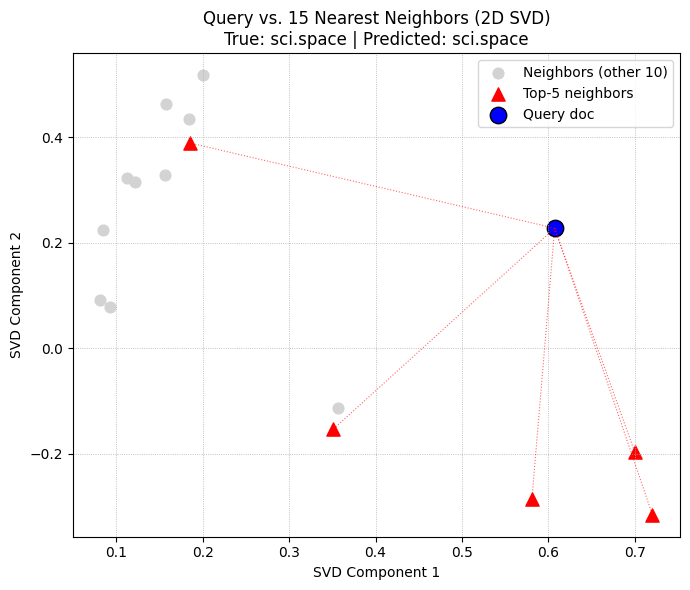

In [ ]:
# === Visualize one test document and its nearest neighbors (2D) ===
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import vstack

# Build local set: query + 15 nearest neighbors (use existing knn results)
n_neighbors_vis = 15
dist_all, idx_all = knn.kneighbors(test_vec, n_neighbors=n_neighbors_vis, return_distance=True)
idx_all = idx_all[0]
dist_all = dist_all[0]

top5_idx = idx_all[:5]
top10_idx = idx_all[5:]  # next 10

# Stack vectors: [query, all 15 neighbors]
X_vis = vstack([test_vec, X_train_tfidf[idx_all]])

# Reduce to 2D for plotting
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_vis)
query_2d = X_2d[0]
nbrs_2d = X_2d[1:]

# Split into top5 and other10
top5_pts = nbrs_2d[:5]
other_pts = nbrs_2d[5:]

# --- Plot ---
plt.figure(figsize=(7, 6))
plt.scatter(other_pts[:,0], other_pts[:,1], c='lightgray', s=60, label='Neighbors (other 10)')
plt.scatter(top5_pts[:,0], top5_pts[:,1], c='red', s=90, marker='^', label='Top-5 neighbors')
plt.scatter([query_2d[0]], [query_2d[1]], c='blue', s=140, edgecolors='black', linewidths=1, label='Query doc')

# Optional dotted lines from query to top5
for p in top5_pts:
    plt.plot([query_2d[0], p[0]], [query_2d[1], p[1]], linestyle=':', linewidth=0.8, c='red', alpha=0.6)

plt.title(f"Query vs. 15 Nearest Neighbors (2D SVD)\nTrue: {true_label} | Predicted: {pred_label}")
plt.xlabel("SVD Component 1"); plt.ylabel("SVD Component 2")
plt.legend()
plt.grid(True, linestyle=':', linewidth=0.6)
plt.tight_layout()
plt.show()


### Wrap-Up: k-Nearest Neighbors (k-NN)

k-Nearest Neighbors is one of the simplest classification algorithms.  
It doesn’t build a mathematical model — instead, it **memorizes the training data**.  
When a new document arrives, the algorithm finds its **k most similar examples** (its *neighbors*)  
based on a distance metric (here we used **cosine distance** on TF-IDF vectors)  
and assigns the class that most of those neighbors belong to.  
If we use *distance weighting*, closer neighbors influence the decision more.  

k-NN works well when similar items truly cluster together in feature space,  
but it can become **slow for large datasets** and **sensitive to the choice of k and distance metric**.


## <font color="blue">Decision Trees</font>

**Key choices**

- **Representation:** TF-IDF vectors (same as before).  
- **Criterion:** *Entropy* (information gain) — encourages more balanced splits for text data.  
- **Max depth:** Start simple (e.g., `max_depth=20`) to prevent overfitting.  
- **Splitter:** *Best* — standard greedy approach.  

**What we’ll report**

- **Accuracy** and **Macro-F1** (treats all categories equally).  
- **Confusion matrix** to see which topics get misclassified.  
- Optional: **Top predictive words** for selected branches (interpretability).


=== Decision Tree (entropy) Results ===
Accuracy : 0.473
Macro-F1 : 0.491

              precision    recall  f1-score   support

           0       0.58      0.50      0.54       195
           1       0.78      0.41      0.54       193
           2       0.92      0.45      0.61       198
           3       0.25      0.80      0.38       198
           4       0.92      0.41      0.57       197
           5       0.45      0.35      0.39       155
           6       0.67      0.29      0.41       126

    accuracy                           0.47      1262
   macro avg       0.65      0.46      0.49      1262
weighted avg       0.66      0.47      0.50      1262



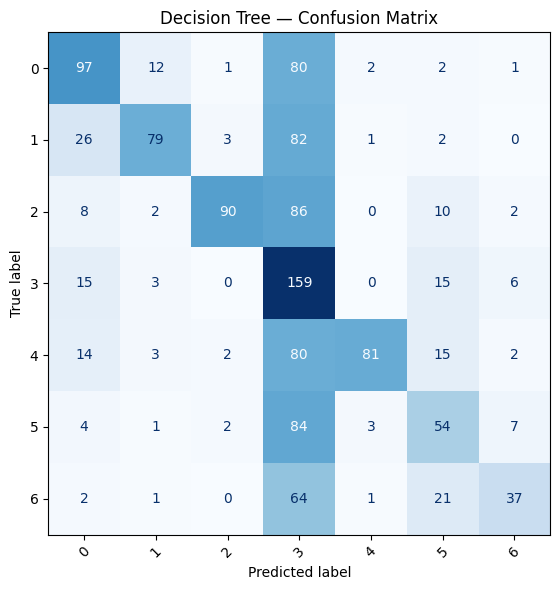

In [ ]:
# Decision Tree — Train & Evaluate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(criterion="entropy", max_depth=20, random_state=42)
dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)
acc_dt = accuracy_score(y_test, y_pred_dt)
macro_f1_dt = f1_score(y_test, y_pred_dt, average="macro")

print("=== Decision Tree (entropy) Results ===")
print(f"Accuracy : {acc_dt:.3f}")
print(f"Macro-F1 : {macro_f1_dt:.3f}\n")
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()


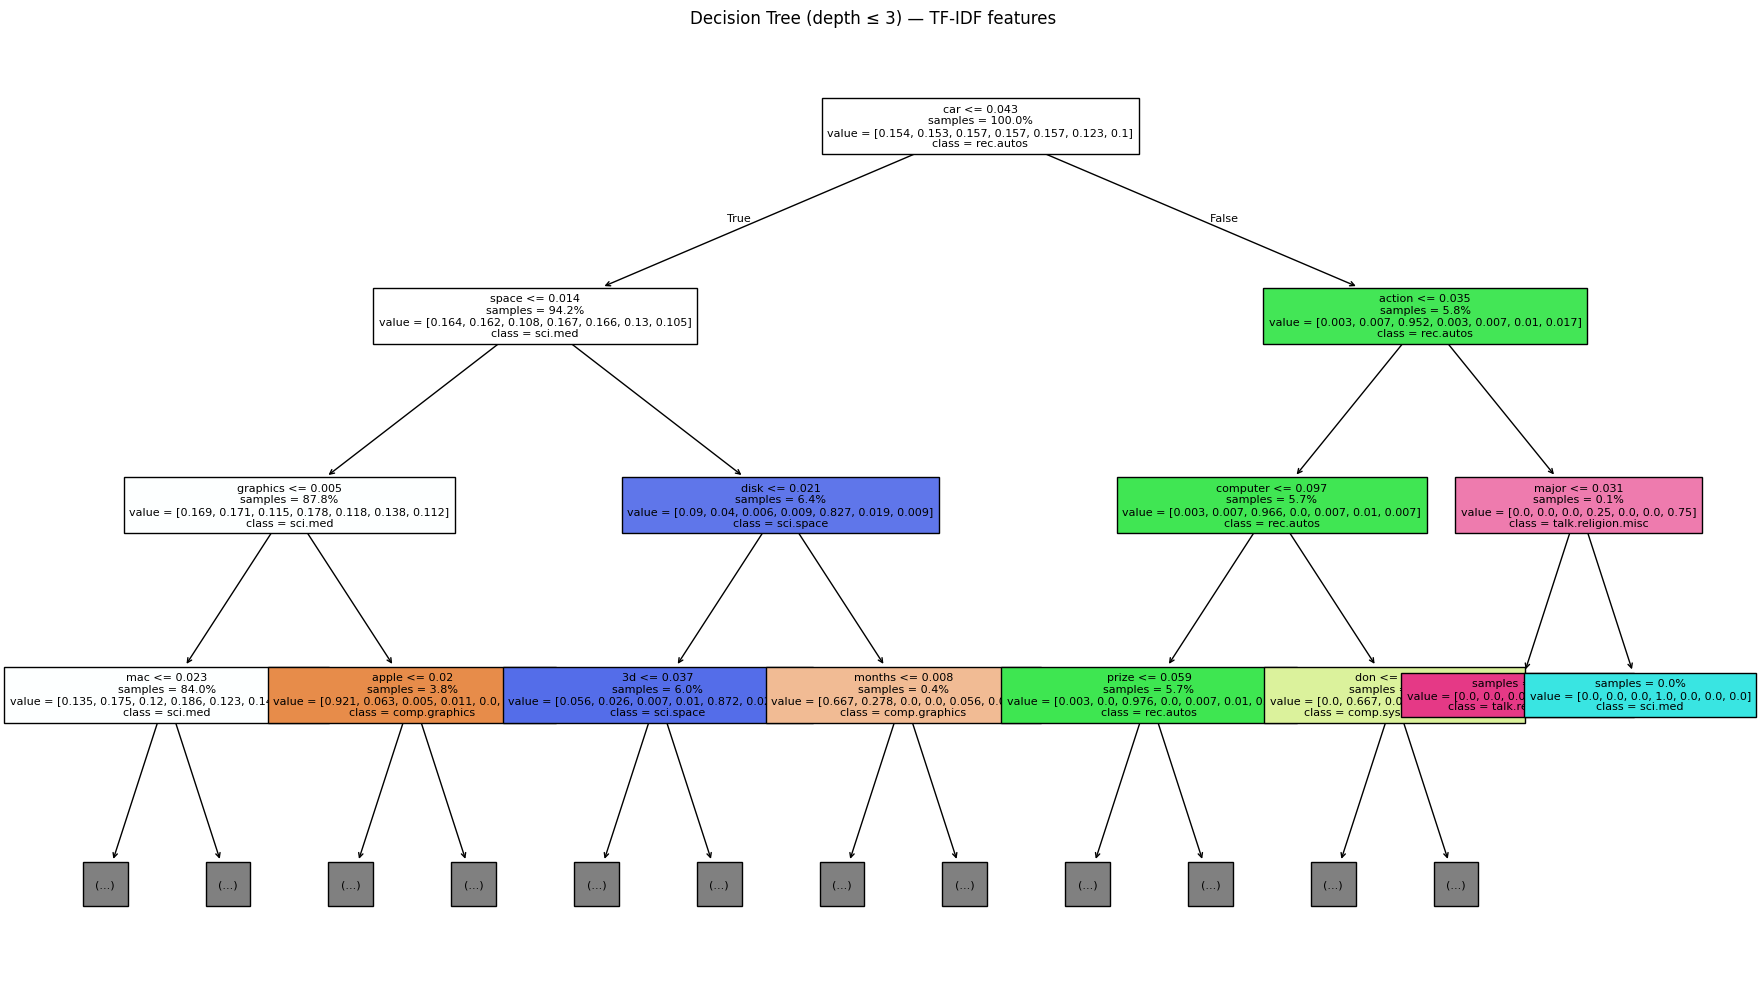

In [ ]:
# Visualize the Decision Tree (top levels for readability)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()

plt.figure(figsize=(18, 10))
plot_tree(
    dt,
    max_depth=3,                    # show only top levels so it's readable
    feature_names=feature_names,
    class_names=newsgroups.target_names,
    filled=True,
    impurity=False,
    proportion=True,
    fontsize=8
)
plt.title("Decision Tree (depth ≤ 3) — TF-IDF features")
plt.tight_layout()
plt.show()


=== Top 15 Predictive Words (by Information Gain) ===

 1. car                        0.1144
 2. space                      0.0895
 3. mac                        0.0663
 4. graphics                   0.0652
 5. god                        0.0479
 6. apple                      0.0479
 7. people                     0.0399
 8. thanks                     0.0317
 9. cars                       0.0279
10. orbit                      0.0235
11. government                 0.0214
12. gordon                     0.0198
13. file                       0.0193
14. doctor                     0.0187
15. 3d                         0.0166


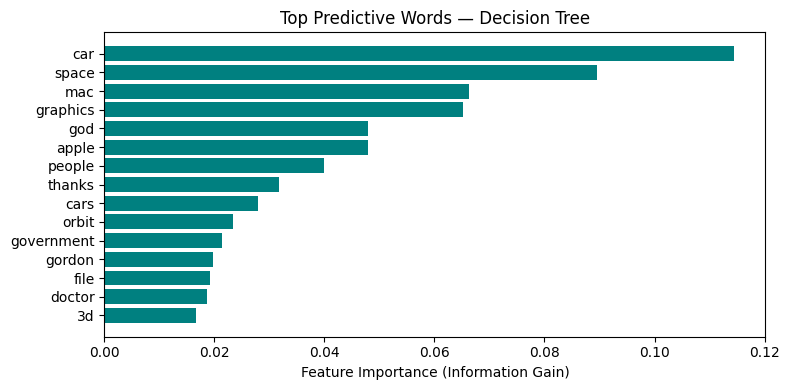

In [ ]:
# Show top predictive words from a few key splits
import numpy as np

# Extract feature importances from the trained Decision Tree
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1][:15]

top_features = [(feature_names[i], importances[i]) for i in indices]

print("=== Top 15 Predictive Words (by Information Gain) ===\n")
for rank, (word, score) in enumerate(top_features, start=1):
    print(f"{rank:2d}. {word:<25}  {score:.4f}")

# --- Visualize them ---
plt.figure(figsize=(8,4))
plt.barh([w for w,_ in reversed(top_features)], [s for _,s in reversed(top_features)], color="teal")
plt.xlabel("Feature Importance (Information Gain)")
plt.title("Top Predictive Words — Decision Tree")
plt.tight_layout()
plt.show()


## <font color="blue">Random Forest</font>

**Key choices**

- **Representation:** TF-IDF vectors (same as Decision Trees).  
- **Base learners:** Many decision trees on bootstrap samples; random subset of features per split (bagging + feature randomness).  
- **Number of trees:** Start with `n_estimators = 300` for stability.  
- **Max depth:** Leave unrestricted initially (ensemble regularizes); cap later if needed (e.g., `max_depth = 20`).  
- **Criterion:** *Entropy* (to mirror Decision Trees).  
- **Class imbalance:** Consider `class_weight='balanced'` if classes are skewed.  

**What we’ll report**

- **Accuracy** and **Macro-F1**.  
- **Confusion matrix** to visualize misclassifications.  



=== Random Forest Results ===
Accuracy : 0.742
Macro-F1 : 0.735

                       precision    recall  f1-score   support

        comp.graphics       0.71      0.85      0.77       195
comp.sys.mac.hardware       0.88      0.76      0.82       193
            rec.autos       0.65      0.81      0.72       198
              sci.med       0.79      0.74      0.76       198
            sci.space       0.79      0.71      0.75       197
   talk.politics.misc       0.70      0.68      0.69       155
   talk.religion.misc       0.70      0.58      0.63       126

             accuracy                           0.74      1262
            macro avg       0.75      0.73      0.73      1262
         weighted avg       0.75      0.74      0.74      1262



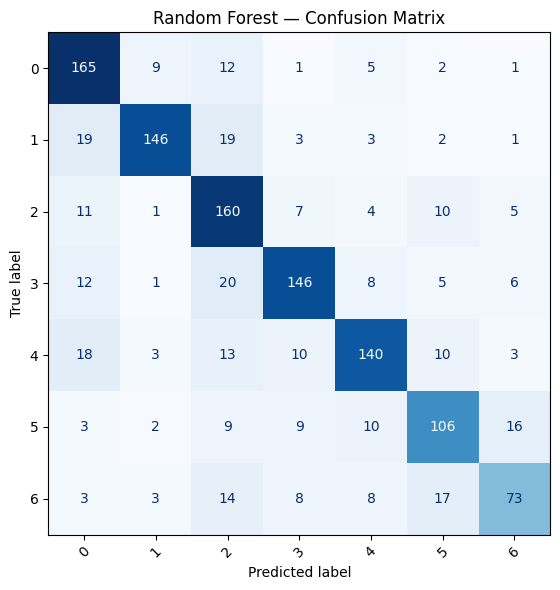

In [ ]:
# Random Forest — Train & Evaluate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Initialize model
rf = RandomForestClassifier(
    n_estimators=400,          # plenty of trees for stable OOB estimates
    criterion="entropy",       # to mirror Decision Tree choice
    max_depth=None,            # let trees grow; ensemble regularizes
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",       # standard for RF; good for high-dim TF-IDF
    bootstrap=True,
    oob_score=True,            # << enable out-of-bag validation
    class_weight="balanced",   # helpful if classes are uneven
    random_state=89
)

# Train
rf.fit(X_train_tfidf, y_train)

# Predict
y_pred_rf = rf.predict(X_test_tfidf)

# Evaluate
acc_rf = accuracy_score(y_test, y_pred_rf)
macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")

print("=== Random Forest Results ===")
print(f"Accuracy : {acc_rf:.3f}")
print(f"Macro-F1 : {macro_f1_rf:.3f}\n")
print(classification_report(y_test, y_pred_rf, target_names=newsgroups.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()


Show the OOB (out-of-bag) accuracy

In [ ]:
# Random Forest — Out-of-Bag generalization estimate from training
try:
    print(f"Out-of-Bag Accuracy : {rf.oob_score_:.3f}")
except AttributeError:
    print("OOB score not available (ensure oob_score=True before fitting).")


Out-of-Bag Accuracy : 0.749


Out-Of-Bag Learning Curve Visualization

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


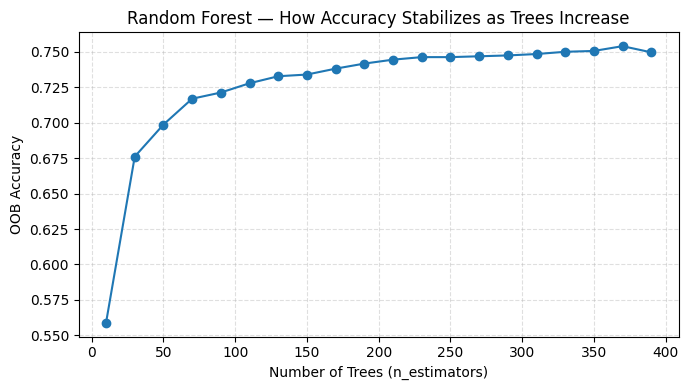

Best OOB Accuracy ≈ 0.754 at ~370 trees


In [ ]:
# Random Forest — OOB Learning Curve Visualization
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

oob_scores = []
n_trees_grid = list(range(10, 401, 20))  # test 10 → 400 trees

rf_curve = RandomForestClassifier(
    n_estimators=0,
    criterion="entropy",
    max_features="sqrt",
    class_weight="balanced",
    bootstrap=True,
    oob_score=True,
    warm_start=True,   # allows incremental growth
    random_state=89
)

for n in n_trees_grid:
    rf_curve.set_params(n_estimators=n)
    rf_curve.fit(X_train_tfidf, y_train)
    oob_scores.append(rf_curve.oob_score_)

plt.figure(figsize=(7,4))
plt.plot(n_trees_grid, oob_scores, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("OOB Accuracy")
plt.title("Random Forest — How Accuracy Stabilizes as Trees Increase")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Best OOB Accuracy ≈ {max(oob_scores):.3f} at ~{n_trees_grid[int(np.argmax(oob_scores))]} trees")


## <font color="blue">Model Comparison & Conclusion</font>

**Test metrics (same split, TF-IDF features)**

| Model | Accuracy | Macro-F1 |
|---|---:|---:|
| Decision Tree (entropy) | **0.473** | **0.491** |
| Random Forest (entropy, OOB) | **0.742** | **0.735** |
| k-NN (cosine) | **0.792** | **0.787** |

<sub>OOB Accuracy (Random Forest): **0.749** — consistent with its test performance.</sub>

### Takeaways
- **k-NN (cosine) performs best** on this TF-IDF text setup. Local neighborhood similarity in high-dimensional sparse space works well when classes are separable by word usage patterns.  
- **Random Forest** is a strong second: bagging + feature randomness reduce variance vs. a single tree, yielding stable performance close to its OOB estimate.  
- **Decision Tree** alone underperforms: a single tree tends to overfit idiosyncratic word splits and lacks the variance reduction of an ensemble.

### When to prefer which
- Choose **k-NN (cosine)** when: feature extraction is TF-IDF/embeddings, training is cheap, and prediction latency is acceptable.  
- Choose **Random Forest** when: you want fast inference, built-in feature importance, and a solid baseline without much tuning.  
- Avoid relying on a **single Decision Tree** for text unless interpretability of a simple structure is the primary goal.


